In [1]:
import kagglehub as kh
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as td
from torch import nn
import torchcurves as tc
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [3]:
file_path = "housing.csv"
df = kh.dataset_load(kh.KaggleDatasetAdapter.PANDAS, "camnugent/california-housing-prices", file_path)

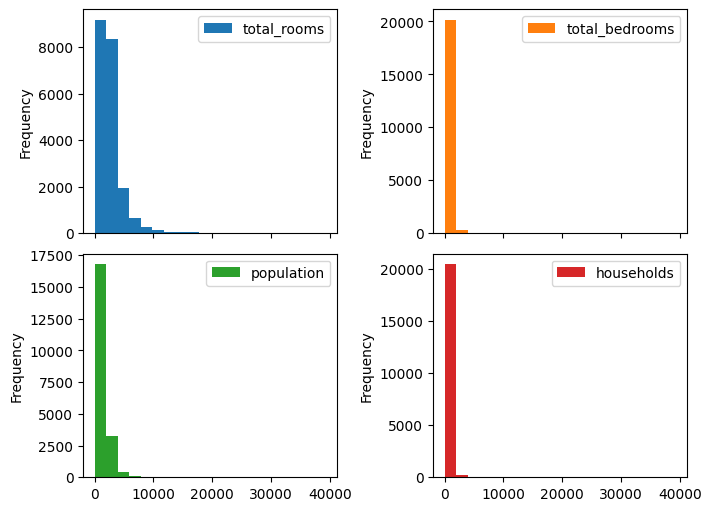

In [4]:
# columns that we know have a very skewed distribution
skewed_columns = ['total_rooms', 'total_bedrooms', 'population', 'households']
df[skewed_columns].plot.hist(bins=20, subplots=True, layout=(2, 2), figsize=(7, 5))
plt.gcf().set_layout_engine('constrained')

In [5]:
df.loc[:, skewed_columns] = df[skewed_columns].apply(np.log)

In [ ]:
num_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_cols = ['ocean_proximity']
num_cat_features = sum(1 + df[col].nunique() for col in cat_cols)
label_col = 'median_house_value'

In [7]:
train_df = df.sample(frac=0.8, random_state=2025)
test_df = df.drop(train_df.index)

# Preprocess data

In [8]:
X_train, y_train = train_df.drop(label_col, axis=1), train_df[[label_col]]
X_test, y_test = test_df.drop(label_col, axis=1), test_df[[label_col]]

In [9]:
feat_preprocessor = make_column_transformer(
    (OrdinalEncoder(), cat_cols),                                 # categorical: ordinal encode
    (make_pipeline(SimpleImputer(), StandardScaler()), num_cols), # numerical: impute then scale
    verbose_feature_names_out=False
).set_output(transform='pandas')
label_preprocessor = StandardScaler()

In [10]:
X_train_pp = feat_preprocessor.fit_transform(X_train)
X_test_pp = feat_preprocessor.transform(X_test)

y_train_pp = label_preprocessor.fit_transform(y_train)
y_test_pp = label_preprocessor.transform(y_test)

In [11]:
X_train_cat = X_train_pp[cat_cols].values
X_train_num = X_train_pp[num_cols].values
X_test_cat = X_test_pp[cat_cols].values
X_test_num = X_test_pp[num_cols].values

# Train and evaluate models

In [12]:
class Transformer(nn.Module):
    def __init__(self, emb_dim, num_heads, num_layers=4, dim_feedforward=128):
        super().__init__()
        self.emb_preprocess = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Dropout(p=0.1)
        )
        layer = nn.TransformerEncoderLayer(
            emb_dim, num_heads, batch_first=True,activation='gelu', dim_feedforward=dim_feedforward
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer=layer,
            num_layers=num_layers
        )
        self.fc = nn.Linear(emb_dim, 1)

    def _compute(self, curve_emb: torch.Tensor, cat_emb: torch.Tensor):
        emb = torch.cat((curve_emb, cat_emb), axis=-2)
        encoded = self.transformer(self.emb_preprocess(emb))
        pooled = torch.mean(encoded, axis=-2)
        return self.fc(pooled)

In [13]:
class BSplineTransformer(Transformer):
    """A factorization machine class with rationally-normalized B-Spline embeddings"""
    def __init__(self, num_cont_features, num_cat_features, emb_dim, num_heads, num_coefs=10):
        super().__init__(emb_dim, num_heads)
        self.register_buffer("offsets", torch.tensor((0, *np.cumsum(num_cat_features)[:-1]), dtype=torch.int32))

        self.pwise_cont_emb = tc.BSplineEmbeddings(
            num_cont_features, emb_dim, knots_config=num_coefs, normalize_fn='rational'
        )
        self.pwise_cat_emb = nn.Embedding(sum(num_cat_features), emb_dim)
        nn.init.xavier_uniform_(self.pwise_cat_emb.weight)

    def forward(self, num: torch.Tensor, cat: torch.Tensor):
        cont_emb = self.pwise_cont_emb(num)
        cat_emb = self.pwise_cat_emb(cat + torch.as_tensor(self.offsets, dtype=cat.dtype).unsqueeze(0))
        return self._compute(cont_emb, cat_emb)

In [14]:
class LegendreTransformer(Transformer):
    """A factorization machine class with rationally-normalized Legendre curve embeddings"""
    def __init__(self, num_cont_features, num_cat_features, emb_dim, num_heads, degree=11):
        super().__init__(emb_dim, num_heads)
        self.register_buffer("offsets", torch.tensor((0, *np.cumsum(num_cat_features)[:-1]), dtype=torch.int32))

        self.pwise_cont_emb = tc.LegendreCurve(
            num_cont_features, emb_dim, degree=degree, normalize_fn='rational'
        )
        self.pwise_cat_emb = nn.Embedding(sum(num_cat_features), emb_dim)
        nn.init.xavier_uniform_(self.pwise_cat_emb.weight)

    def forward(self, num: torch.Tensor, cat: torch.Tensor):
        cont_emb = self.pwise_cont_emb(num)
        cat_emb = self.pwise_cat_emb(cat + torch.as_tensor(self.offsets, dtype=cat.dtype).unsqueeze(0))
        return self._compute(cont_emb, cat_emb)

In [15]:
num_epochs = 100
print_every = 10
batch_size = 64
lr = 1e-4
emb_dim = 32
num_heads = 4

num_features = X_train_pp.shape[1]
train_set_size = len(X_train_pp)
test_set_size = len(X_test_pp)

In [16]:
train_ds = td.TensorDataset(
        torch.as_tensor(X_train_num, dtype=torch.float32),
        torch.as_tensor(X_train_cat, dtype=torch.int32),
        torch.as_tensor(y_train_pp, dtype=torch.float32)
    )
eval_ds = td.TensorDataset(
        torch.as_tensor(X_test_num, dtype=torch.float32),
        torch.as_tensor(X_test_cat, dtype=torch.int32),
        torch.as_tensor(y_test_pp, dtype=torch.float32)
    )

In [17]:
def train_epoch(model, optim, criterion, train_dl):
    tr_loss = 0.
    for xnum, xcat, yb in train_dl:
        xnum = xnum.to(device)
        xcat = xcat.to(device)
        yb = yb.to(device)

        pred = model(xnum, xcat)
        loss = criterion(yb, pred)

        optim.zero_grad()
        loss.backward()
        optim.step()

        tr_loss += loss * torch.numel(yb)
    return tr_loss.item() / train_set_size


@torch.no_grad
def eval_epoch(model, eval_criterion, eval_dl):
    eval_total_error = 0.
    for xnum, xcat, yb in eval_dl:
        # predict
        pred = model(xnum.to(device), xcat.to(device))

        # compute label and prediction in terms of the original, unscaled labels
        label_orig = label_preprocessor.inverse_transform(yb.view(-1, 1))
        pred_orig = label_preprocessor.inverse_transform(pred.cpu().view(-1, 1))

        # compute loss on the original labels
        loss = eval_criterion(
            torch.as_tensor(label_orig, device=device, dtype=torch.float32),
            torch.as_tensor(pred_orig, device=device, dtype=torch.float32)
        )
        eval_total_error += loss * torch.numel(yb)
    return eval_total_error.item() / test_set_size

In [18]:
def train_eval_model(name, model: nn.Module, batch_size: int, print_progress=True, **optim_kwargs):
    model = model.to(device)
    optim = torch.optim.AdamW(model.parameters(), **optim_kwargs)
    criterion = nn.MSELoss()
    train_dl = td.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    eval_dl = td.DataLoader(eval_ds, batch_size=128)

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = train_epoch(model, optim, criterion, train_dl)

        model.eval()
        eval_loss = eval_epoch(model, criterion, eval_dl)
        eval_rmse = math.sqrt(eval_loss)

        if print_progress and (epoch % print_every == 0 or epoch == num_epochs):
            print(f'[{name}] Epoch {epoch}, tr loss = {train_loss:.4f}, eval RMSE = {eval_rmse:.2f}')

    return model

In [19]:
bspline_model = train_eval_model(
    "BSpline",
    BSplineTransformer(len(num_cols), [num_cat_features], emb_dim, num_heads),
    lr=1e-4, weight_decay=1e-3, batch_size=batch_size
)


[BSpline] Epoch 10, tr loss = 0.2639, eval RMSE = 55457.92
[BSpline] Epoch 20, tr loss = 0.2342, eval RMSE = 53431.27
[BSpline] Epoch 30, tr loss = 0.2151, eval RMSE = 52751.59
[BSpline] Epoch 40, tr loss = 0.2064, eval RMSE = 52443.17
[BSpline] Epoch 50, tr loss = 0.2016, eval RMSE = 51544.23
[BSpline] Epoch 60, tr loss = 0.1962, eval RMSE = 51868.74
[BSpline] Epoch 70, tr loss = 0.1868, eval RMSE = 50139.31
[BSpline] Epoch 80, tr loss = 0.1803, eval RMSE = 50207.11
[BSpline] Epoch 90, tr loss = 0.1787, eval RMSE = 49997.67
[BSpline] Epoch 100, tr loss = 0.1713, eval RMSE = 49812.17


In [20]:
legendre_model = train_eval_model(
    "Legendre",
    LegendreTransformer(len(num_cols), [num_cat_features], emb_dim, num_heads),
    lr=1e-4, weight_decay=1e-3, batch_size=batch_size
)

[Legendre] Epoch 10, tr loss = 0.2698, eval RMSE = 56211.90
[Legendre] Epoch 20, tr loss = 0.2282, eval RMSE = 53538.53
[Legendre] Epoch 30, tr loss = 0.2130, eval RMSE = 51634.45
[Legendre] Epoch 40, tr loss = 0.2034, eval RMSE = 50222.74
[Legendre] Epoch 50, tr loss = 0.1898, eval RMSE = 49057.27
[Legendre] Epoch 60, tr loss = 0.1838, eval RMSE = 49007.72
[Legendre] Epoch 70, tr loss = 0.1777, eval RMSE = 48858.45
[Legendre] Epoch 80, tr loss = 0.1731, eval RMSE = 48522.82
[Legendre] Epoch 90, tr loss = 0.1695, eval RMSE = 48271.63
[Legendre] Epoch 100, tr loss = 0.1668, eval RMSE = 48415.41


In [21]:
highdeg_legendre_model = train_eval_model(
    "Legendre-HiDeg",
    LegendreTransformer(len(num_cols), [num_cat_features], emb_dim, num_heads, degree=50),
    lr=1e-4, weight_decay=1e-3, batch_size=batch_size
)

[Legendre-HiDeg] Epoch 10, tr loss = 0.2178, eval RMSE = 51721.63
[Legendre-HiDeg] Epoch 20, tr loss = 0.1840, eval RMSE = 49726.78
[Legendre-HiDeg] Epoch 30, tr loss = 0.1650, eval RMSE = 49347.07
[Legendre-HiDeg] Epoch 40, tr loss = 0.1508, eval RMSE = 49602.88
[Legendre-HiDeg] Epoch 50, tr loss = 0.1398, eval RMSE = 49327.19
[Legendre-HiDeg] Epoch 60, tr loss = 0.1331, eval RMSE = 50191.33
[Legendre-HiDeg] Epoch 70, tr loss = 0.1235, eval RMSE = 50108.65
[Legendre-HiDeg] Epoch 80, tr loss = 0.1171, eval RMSE = 50796.85
[Legendre-HiDeg] Epoch 90, tr loss = 0.1116, eval RMSE = 50325.89
[Legendre-HiDeg] Epoch 100, tr loss = 0.1085, eval RMSE = 49951.41


In [22]:
very_highdeg_legendre_model = train_eval_model(
    "Legendre-HiDeg",
    LegendreTransformer(len(num_cols), [num_cat_features], emb_dim, num_heads, degree=500),
    lr=1e-4, weight_decay=1e-3, batch_size=batch_size
)

[Legendre-HiDeg] Epoch 10, tr loss = 0.1206, eval RMSE = 55855.46
[Legendre-HiDeg] Epoch 20, tr loss = 0.0686, eval RMSE = 57536.23
[Legendre-HiDeg] Epoch 30, tr loss = 0.0507, eval RMSE = 56806.41
[Legendre-HiDeg] Epoch 40, tr loss = 0.0397, eval RMSE = 57998.25
[Legendre-HiDeg] Epoch 50, tr loss = 0.0355, eval RMSE = 57732.67
[Legendre-HiDeg] Epoch 60, tr loss = 0.0309, eval RMSE = 57050.37
[Legendre-HiDeg] Epoch 70, tr loss = 0.0280, eval RMSE = 57061.53
[Legendre-HiDeg] Epoch 80, tr loss = 0.0252, eval RMSE = 57497.48
[Legendre-HiDeg] Epoch 90, tr loss = 0.0240, eval RMSE = 56502.04
[Legendre-HiDeg] Epoch 100, tr loss = 0.0225, eval RMSE = 57353.50


# Plot fit functions

In [23]:
def plot_model(model):
    _, axs = plt.subplots(1, 2, figsize=(8, 3))
    axs[0].scatter(X_test_num[:, 0], X_test_num[:, 1], s=1,
                c=model(torch.as_tensor(X_test_num).float(), torch.as_tensor(X_test_cat).int()).detach().numpy())
    axs[1].scatter(X_test_num[:, 0], X_test_num[:, 1], s=1, c=y_test_pp)
    axs[0].set_title("Model")
    axs[1].set_title("Label")
    plt.show()

/Users/alex.shtoff/git/torchcurves/src/torchcurves/bspline.py:83: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:34.)
  spans = torch.searchsorted(knots, u, side="right") - 1


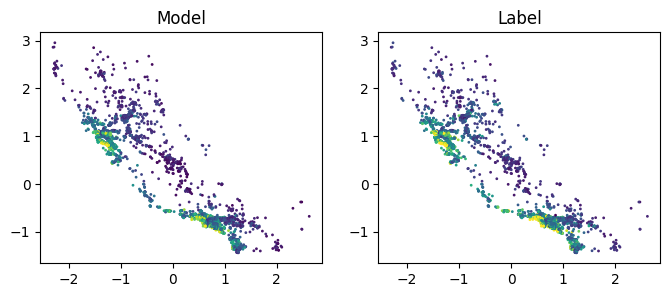

In [24]:
plot_model(bspline_model)

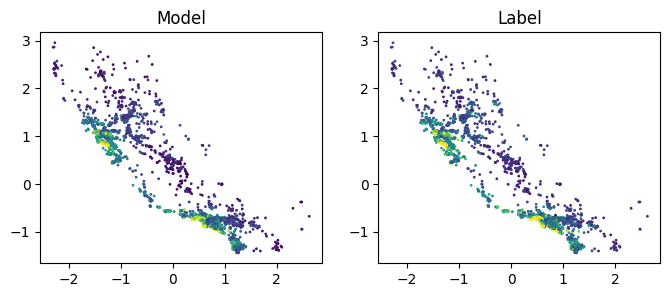

In [25]:
plot_model(legendre_model)

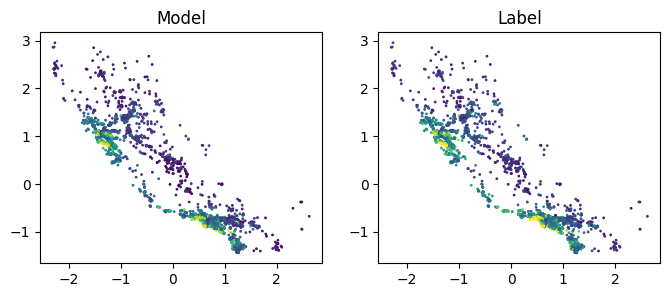

In [26]:
plot_model(highdeg_legendre_model)

### Plot highdeg spectrum

In [27]:
coefficients = very_highdeg_legendre_model.pwise_cont_emb.coefficients
num_curves, num_coefs, dim =coefficients.shape
coefficient_norms = torch.linalg.vector_norm(coefficients, ord=1, dim=-1)

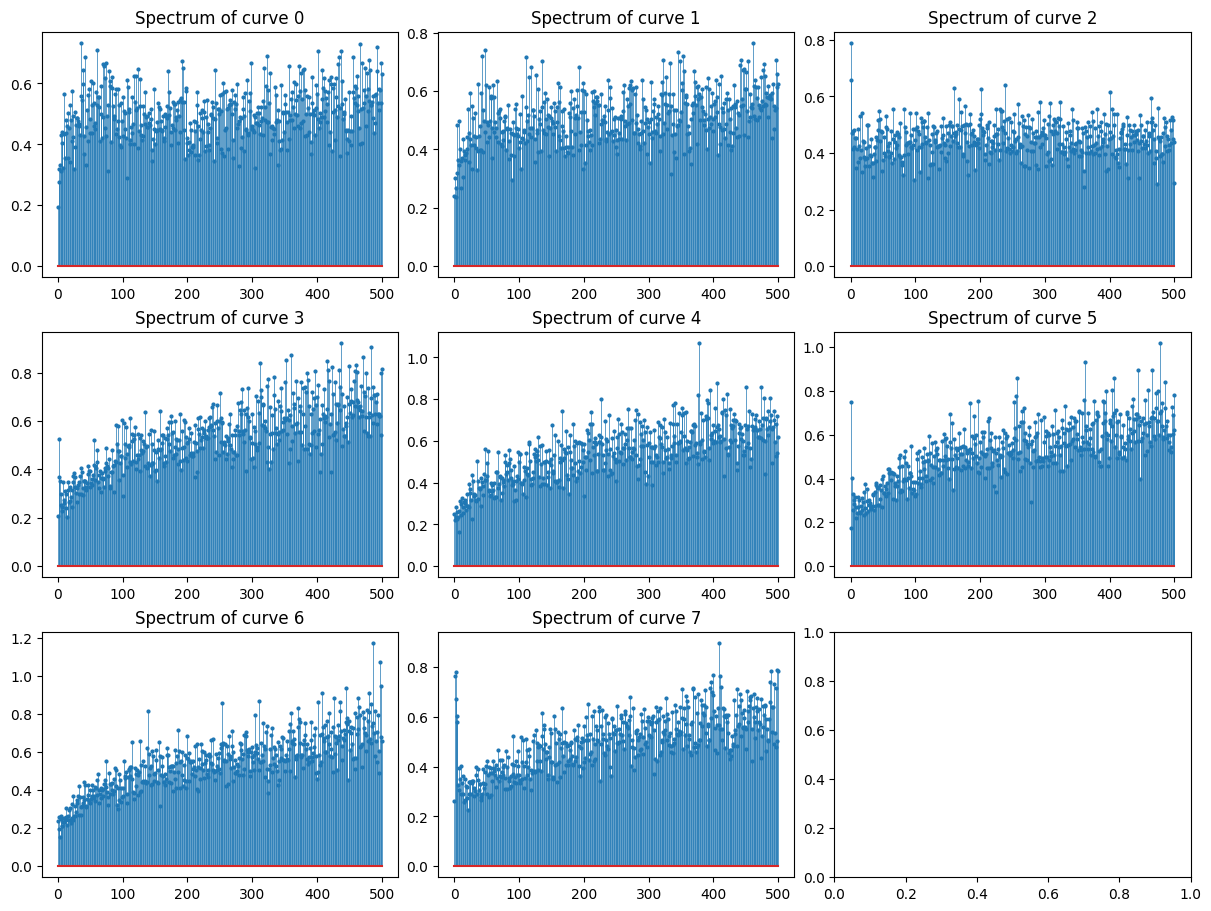

In [28]:
def plot_coefs(ax, norms, ix):
    markerline, stemline, _, = ax.stem(norms.detach())
    plt.setp(stemline, linewidth=0.5)
    plt.setp(markerline, markersize=2)
    ax.set_title(f"Spectrum of curve {ix}")

nrows = math.ceil(math.sqrt(num_curves))
ncols = math.ceil(num_curves / nrows)
fig, axs = plt.subplots(nrows, ncols, layout="constrained", figsize=(4 * ncols, 3 * nrows))
for ix, ax in enumerate(axs.ravel()):
    if ix > len(coefficient_norms) - 1:
        break
    plot_coefs(ax, coefficient_norms[ix], ix)
plt.show()

In [35]:
spectral_cols = [3, 4, 5, 6, 7]
spatial_cols = [0, 1, 2]

In [37]:
[df.columns[i] for i in spectral_cols], [df.columns[i] for i in spatial_cols]

(['total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income'],
 ['longitude', 'latitude', 'housing_median_age'])

In [ ]:
# TODO - divide it into spatial and spectral features
